In [1]:
!pip -q install tensorboard

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Keeping the seeds fixed so my results stay reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cpu


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Using the same image dataset from the synthetic student wellness dataset
base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/images"
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))
print("Class folders:", os.listdir(train_dir))

Train exists: True
Test exists: True
Class folders: ['high_risk', 'moderate_risk', 'low_risk', 'critical_risk']


In [5]:
# Loading the image data for TensorFlow
image_size = (64, 64)
batch_size = 32

tf_train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=image_size,
    batch_size=batch_size
)

tf_val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=image_size,
    batch_size=batch_size
)

tf_test_ds = image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = tf_train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
tf_train_ds = tf_train_ds.prefetch(AUTOTUNE)
tf_val_ds = tf_val_ds.prefetch(AUTOTUNE)
tf_test_ds = tf_test_ds.prefetch(AUTOTUNE)

print("Class names:", class_names)

Found 240 files belonging to 4 classes.
Using 192 files for training.
Found 240 files belonging to 4 classes.
Using 48 files for validation.
Found 80 files belonging to 4 classes.
Class names: ['critical_risk', 'high_risk', 'low_risk', 'moderate_risk']


In [6]:
# Loading the same image data for PyTorch
torch_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

torch_train_dataset_full = datasets.ImageFolder(train_dir, transform=torch_transform)
torch_test_dataset = datasets.ImageFolder(test_dir, transform=torch_transform)

train_size = int(0.8 * len(torch_train_dataset_full))
val_size = len(torch_train_dataset_full) - train_size

torch_train_dataset, torch_val_dataset = torch.utils.data.random_split(
    torch_train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

torch_train_loader = DataLoader(torch_train_dataset, batch_size=32, shuffle=True)
torch_val_loader = DataLoader(torch_val_dataset, batch_size=32, shuffle=False)
torch_test_loader = DataLoader(torch_test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [7]:
# This custom dropout layer is just my own version instead of the built-in one
class MyDropout(layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training:
            keep_mask = tf.cast(
                tf.random.uniform(tf.shape(inputs)) > self.rate,
                dtype=inputs.dtype
            )
            return inputs * keep_mask / (1.0 - self.rate)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate})
        return config

In [8]:
# This is a custom L1+L2 regularizer so I can show custom regularization too
class MyL1L2Regularizer(regularizers.Regularizer):
    def __init__(self, l1=0.0, l2=0.0):
        self.l1 = l1
        self.l2 = l2

    def __call__(self, weights):
        l1_penalty = self.l1 * tf.reduce_sum(tf.abs(weights))
        l2_penalty = self.l2 * tf.reduce_sum(tf.square(weights))
        return l1_penalty + l2_penalty

    def get_config(self):
        return {"l1": self.l1, "l2": self.l2}

In [9]:
# Helper function to build TensorFlow models for different experiments
def build_tf_model(
    initializer="glorot_uniform",
    use_builtin_dropout=True,
    use_custom_dropout=False,
    regularizer=None,
    dropout_rate=0.3
):
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_initializer=initializer,
                      kernel_regularizer=regularizer),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu",
                      kernel_initializer=initializer,
                      kernel_regularizer=regularizer),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu",
                     kernel_initializer=initializer,
                     kernel_regularizer=regularizer),
    ])

    if use_builtin_dropout:
        model.add(layers.Dropout(dropout_rate))

    if use_custom_dropout:
        model.add(MyDropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [10]:
# Simple helper so all TF experiments are trained in the same way
def train_tf_model(model, name, epochs=10):
    history = model.fit(
        tf_train_ds,
        validation_data=tf_val_ds,
        epochs=epochs,
        verbose=0
    )
    test_loss, test_acc = model.evaluate(tf_test_ds, verbose=0)
    print(f"{name} -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
    return history, test_acc

In [11]:
# A/B test for different TensorFlow initializers
tf_glorot = build_tf_model(initializer="glorot_uniform", use_builtin_dropout=False)
hist_tf_glorot, acc_tf_glorot = train_tf_model(tf_glorot, "TF Glorot")

tf_he = build_tf_model(initializer="he_normal", use_builtin_dropout=False)
hist_tf_he, acc_tf_he = train_tf_model(tf_he, "TF He Normal")

tf_orth = build_tf_model(initializer="orthogonal", use_builtin_dropout=False)
hist_tf_orth, acc_tf_orth = train_tf_model(tf_orth, "TF Orthogonal")

TF Glorot -> Test Accuracy: 1.0000, Test Loss: 0.0023
TF He Normal -> Test Accuracy: 1.0000, Test Loss: 0.0241
TF Orthogonal -> Test Accuracy: 1.0000, Test Loss: 0.0066


In [12]:
# Built-in dropout vs custom dropout
tf_builtin_dropout = build_tf_model(use_builtin_dropout=True, use_custom_dropout=False)
hist_tf_builtin_dropout, acc_tf_builtin_dropout = train_tf_model(tf_builtin_dropout, "TF Built-in Dropout")

tf_custom_dropout = build_tf_model(use_builtin_dropout=False, use_custom_dropout=True)
hist_tf_custom_dropout, acc_tf_custom_dropout = train_tf_model(tf_custom_dropout, "TF Custom Dropout")

TF Built-in Dropout -> Test Accuracy: 1.0000, Test Loss: 0.0048
TF Custom Dropout -> Test Accuracy: 0.9875, Test Loss: 0.1635


In [13]:
# Testing custom regularization
tf_custom_reg = build_tf_model(
    use_builtin_dropout=False,
    regularizer=MyL1L2Regularizer(l1=1e-5, l2=1e-4)
)
hist_tf_custom_reg, acc_tf_custom_reg = train_tf_model(tf_custom_reg, "TF Custom Regularization")

TF Custom Regularization -> Test Accuracy: 1.0000, Test Loss: 0.1159


In [14]:
# Monte Carlo dropout means I keep dropout active during inference
tf_mc_model = build_tf_model(use_builtin_dropout=True, dropout_rate=0.4)
tf_mc_model.fit(tf_train_ds, validation_data=tf_val_ds, epochs=8, verbose=0)

def mc_dropout_predict_tf(model, images, n_passes=15):
    all_preds = []
    for _ in range(n_passes):
        preds = model(images, training=True)
        all_preds.append(preds.numpy())
    all_preds = np.array(all_preds)
    return all_preds.mean(axis=0), all_preds.std(axis=0)

for sample_images, sample_labels in tf_test_ds.take(1):
    mean_preds, std_preds = mc_dropout_predict_tf(tf_mc_model, sample_images[:5], n_passes=15)
    predicted_classes = np.argmax(mean_preds, axis=1)

    for i in range(5):
        print(
            f"Sample {i+1} | True: {class_names[sample_labels[i]]} | "
            f"Pred: {class_names[predicted_classes[i]]} | "
            f"Uncertainty: {std_preds[i].mean():.4f}"
        )

Sample 1 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0971
Sample 2 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0543
Sample 3 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0514
Sample 4 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0563
Sample 5 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0732


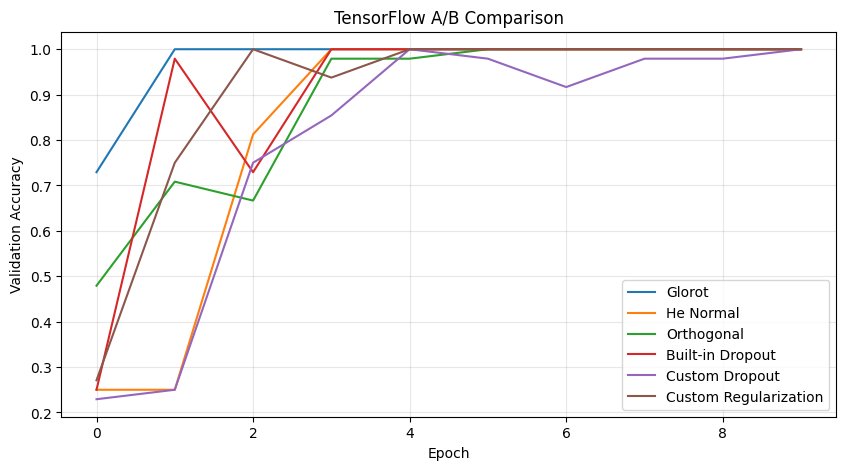

In [15]:
# Comparing TensorFlow validation accuracy for the different experiments
plt.figure(figsize=(10, 5))
plt.plot(hist_tf_glorot.history["val_accuracy"], label="Glorot")
plt.plot(hist_tf_he.history["val_accuracy"], label="He Normal")
plt.plot(hist_tf_orth.history["val_accuracy"], label="Orthogonal")
plt.plot(hist_tf_builtin_dropout.history["val_accuracy"], label="Built-in Dropout")
plt.plot(hist_tf_custom_dropout.history["val_accuracy"], label="Custom Dropout")
plt.plot(hist_tf_custom_reg.history["val_accuracy"], label="Custom Regularization")
plt.title("TensorFlow A/B Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# My own custom dropout layer in PyTorch
class MyDropoutPT(nn.Module):
    def __init__(self, rate=0.3):
        super().__init__()
        self.rate = rate

    def forward(self, x):
        if self.training:
            mask = (torch.rand_like(x) > self.rate).float()
            return x * mask / (1.0 - self.rate)
        return x

In [17]:
# This model lets me switch between built-in dropout and custom dropout
class TorchExperimentNet(nn.Module):
    def __init__(self, dropout_rate=0.3, use_builtin_dropout=True, use_custom_dropout=False):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate) if use_builtin_dropout else None
        self.custom_dropout = MyDropoutPT(dropout_rate) if use_custom_dropout else None
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))

        if self.dropout is not None:
            x = self.dropout(x)

        if self.custom_dropout is not None:
            x = self.custom_dropout(x)

        x = self.fc2(x)
        return x

In [18]:
# This helper applies different initialization methods to conv and linear layers
def initialize_weights(model, method="xavier"):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if method == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif method == "he":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif method == "orthogonal":
                nn.init.orthogonal_(m.weight)

            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

In [19]:
# Training helper for the PyTorch experiments
def train_torch_model(model, train_loader, val_loader, test_loader, name, epochs=8, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    val_acc_history = []

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                correct += (preds.argmax(dim=1) == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total
        val_acc_history.append(val_acc)
        print(f"{name} | Epoch {epoch+1}/{epochs} | Val Accuracy: {val_acc:.4f}")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            correct += (preds.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)

    test_acc = correct / total
    print(f"{name} -> Test Accuracy: {test_acc:.4f}")

    return val_acc_history, test_acc

In [20]:
# A/B test for initializers in PyTorch
torch_xavier = initialize_weights(TorchExperimentNet(use_builtin_dropout=False), "xavier")
hist_torch_xavier, acc_torch_xavier = train_torch_model(
    torch_xavier, torch_train_loader, torch_val_loader, torch_test_loader, "Torch Xavier"
)

torch_he = initialize_weights(TorchExperimentNet(use_builtin_dropout=False), "he")
hist_torch_he, acc_torch_he = train_torch_model(
    torch_he, torch_train_loader, torch_val_loader, torch_test_loader, "Torch He"
)

torch_orth = initialize_weights(TorchExperimentNet(use_builtin_dropout=False), "orthogonal")
hist_torch_orth, acc_torch_orth = train_torch_model(
    torch_orth, torch_train_loader, torch_val_loader, torch_test_loader, "Torch Orthogonal"
)

Torch Xavier | Epoch 1/8 | Val Accuracy: 0.3542
Torch Xavier | Epoch 2/8 | Val Accuracy: 0.3958
Torch Xavier | Epoch 3/8 | Val Accuracy: 0.3958
Torch Xavier | Epoch 4/8 | Val Accuracy: 0.9583
Torch Xavier | Epoch 5/8 | Val Accuracy: 1.0000
Torch Xavier | Epoch 6/8 | Val Accuracy: 1.0000
Torch Xavier | Epoch 7/8 | Val Accuracy: 1.0000
Torch Xavier | Epoch 8/8 | Val Accuracy: 1.0000
Torch Xavier -> Test Accuracy: 1.0000
Torch He | Epoch 1/8 | Val Accuracy: 0.2500
Torch He | Epoch 2/8 | Val Accuracy: 0.3958
Torch He | Epoch 3/8 | Val Accuracy: 0.7500
Torch He | Epoch 4/8 | Val Accuracy: 1.0000
Torch He | Epoch 5/8 | Val Accuracy: 1.0000
Torch He | Epoch 6/8 | Val Accuracy: 1.0000
Torch He | Epoch 7/8 | Val Accuracy: 1.0000
Torch He | Epoch 8/8 | Val Accuracy: 1.0000
Torch He -> Test Accuracy: 1.0000
Torch Orthogonal | Epoch 1/8 | Val Accuracy: 0.2292
Torch Orthogonal | Epoch 2/8 | Val Accuracy: 0.8125
Torch Orthogonal | Epoch 3/8 | Val Accuracy: 1.0000
Torch Orthogonal | Epoch 4/8 | Val A

In [21]:
# Built-in dropout vs custom dropout in PyTorch
torch_builtin_dropout = TorchExperimentNet(use_builtin_dropout=True, use_custom_dropout=False)
hist_torch_builtin_dropout, acc_torch_builtin_dropout = train_torch_model(
    torch_builtin_dropout, torch_train_loader, torch_val_loader, torch_test_loader, "Torch Built-in Dropout"
)

torch_custom_dropout = TorchExperimentNet(use_builtin_dropout=False, use_custom_dropout=True)
hist_torch_custom_dropout, acc_torch_custom_dropout = train_torch_model(
    torch_custom_dropout, torch_train_loader, torch_val_loader, torch_test_loader, "Torch Custom Dropout"
)

Torch Built-in Dropout | Epoch 1/8 | Val Accuracy: 0.3542
Torch Built-in Dropout | Epoch 2/8 | Val Accuracy: 0.4792
Torch Built-in Dropout | Epoch 3/8 | Val Accuracy: 0.7708
Torch Built-in Dropout | Epoch 4/8 | Val Accuracy: 0.5833
Torch Built-in Dropout | Epoch 5/8 | Val Accuracy: 1.0000
Torch Built-in Dropout | Epoch 6/8 | Val Accuracy: 1.0000
Torch Built-in Dropout | Epoch 7/8 | Val Accuracy: 1.0000
Torch Built-in Dropout | Epoch 8/8 | Val Accuracy: 1.0000
Torch Built-in Dropout -> Test Accuracy: 0.9875
Torch Custom Dropout | Epoch 1/8 | Val Accuracy: 0.3958
Torch Custom Dropout | Epoch 2/8 | Val Accuracy: 0.5833
Torch Custom Dropout | Epoch 3/8 | Val Accuracy: 0.9583
Torch Custom Dropout | Epoch 4/8 | Val Accuracy: 1.0000
Torch Custom Dropout | Epoch 5/8 | Val Accuracy: 1.0000
Torch Custom Dropout | Epoch 6/8 | Val Accuracy: 1.0000
Torch Custom Dropout | Epoch 7/8 | Val Accuracy: 1.0000
Torch Custom Dropout | Epoch 8/8 | Val Accuracy: 1.0000
Torch Custom Dropout -> Test Accuracy: 1

In [22]:
# For custom regularization in PyTorch, I am using weight decay as the easier comparison
torch_custom_reg = TorchExperimentNet(use_builtin_dropout=False, use_custom_dropout=False)
hist_torch_custom_reg, acc_torch_custom_reg = train_torch_model(
    torch_custom_reg, torch_train_loader, torch_val_loader, torch_test_loader,
    "Torch Weight Decay", weight_decay=1e-4
)

Torch Weight Decay | Epoch 1/8 | Val Accuracy: 0.1667
Torch Weight Decay | Epoch 2/8 | Val Accuracy: 0.9167
Torch Weight Decay | Epoch 3/8 | Val Accuracy: 0.9583
Torch Weight Decay | Epoch 4/8 | Val Accuracy: 1.0000
Torch Weight Decay | Epoch 5/8 | Val Accuracy: 1.0000
Torch Weight Decay | Epoch 6/8 | Val Accuracy: 1.0000
Torch Weight Decay | Epoch 7/8 | Val Accuracy: 1.0000
Torch Weight Decay | Epoch 8/8 | Val Accuracy: 1.0000
Torch Weight Decay -> Test Accuracy: 1.0000


In [23]:
# Monte Carlo dropout in PyTorch means keeping dropout on at inference time too
torch_mc_model = TorchExperimentNet(use_builtin_dropout=True, dropout_rate=0.4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(torch_mc_model.parameters(), lr=1e-3)

for epoch in range(6):
    torch_mc_model.train()
    for xb, yb in torch_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(torch_mc_model(xb), yb)
        loss.backward()
        optimizer.step()

def mc_dropout_predict_torch(model, images, n_passes=15):
    model.train()
    preds = []
    with torch.no_grad():
        for _ in range(n_passes):
            out = torch.softmax(model(images), dim=1)
            preds.append(out.cpu().numpy())
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

for xb, yb in torch_test_loader:
    xb, yb = xb.to(device), yb.to(device)
    mean_preds, std_preds = mc_dropout_predict_torch(torch_mc_model, xb[:5], n_passes=15)
    pred_classes = np.argmax(mean_preds, axis=1)

    for i in range(5):
        print(
            f"Sample {i+1} | True: {class_names[yb[i].item()]} | "
            f"Pred: {class_names[pred_classes[i]]} | "
            f"Uncertainty: {std_preds[i].mean():.4f}"
        )
    break

Sample 1 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0492
Sample 2 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0420
Sample 3 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0660
Sample 4 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0456
Sample 5 | True: critical_risk | Pred: critical_risk | Uncertainty: 0.0500


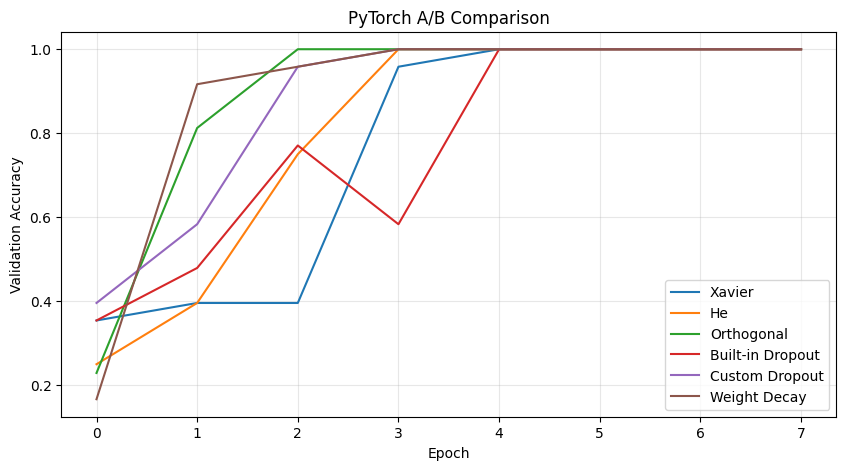

In [24]:
# Comparing the PyTorch validation accuracy curves
plt.figure(figsize=(10, 5))
plt.plot(hist_torch_xavier, label="Xavier")
plt.plot(hist_torch_he, label="He")
plt.plot(hist_torch_orth, label="Orthogonal")
plt.plot(hist_torch_builtin_dropout, label="Built-in Dropout")
plt.plot(hist_torch_custom_dropout, label="Custom Dropout")
plt.plot(hist_torch_custom_reg, label="Weight Decay")
plt.title("PyTorch A/B Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
# Final summary so the main results are easier to explain in the video
print("TensorFlow results")
print("-" * 45)
print(f"Glorot Initializer     : {acc_tf_glorot:.4f}")
print(f"He Normal Initializer  : {acc_tf_he:.4f}")
print(f"Orthogonal Initializer : {acc_tf_orth:.4f}")
print(f"Built-in Dropout       : {acc_tf_builtin_dropout:.4f}")
print(f"Custom Dropout         : {acc_tf_custom_dropout:.4f}")
print(f"Custom Regularization  : {acc_tf_custom_reg:.4f}")

print("\nPyTorch results")
print("-" * 45)
print(f"Xavier Initializer     : {acc_torch_xavier:.4f}")
print(f"He Initializer         : {acc_torch_he:.4f}")
print(f"Orthogonal Initializer : {acc_torch_orth:.4f}")
print(f"Built-in Dropout       : {acc_torch_builtin_dropout:.4f}")
print(f"Custom Dropout         : {acc_torch_custom_dropout:.4f}")
print(f"Weight Decay           : {acc_torch_custom_reg:.4f}")

TensorFlow results
---------------------------------------------
Glorot Initializer     : 1.0000
He Normal Initializer  : 1.0000
Orthogonal Initializer : 1.0000
Built-in Dropout       : 1.0000
Custom Dropout         : 0.9875
Custom Regularization  : 1.0000

PyTorch results
---------------------------------------------
Xavier Initializer     : 1.0000
He Initializer         : 1.0000
Orthogonal Initializer : 1.0000
Built-in Dropout       : 0.9875
Custom Dropout         : 1.0000
Weight Decay           : 1.0000


### Final Observation

In this notebook, I focused on generalization-related ideas like Monte Carlo dropout, initializer comparison, custom dropout, and custom regularization in both TensorFlow and PyTorch. I used A/B style experiments to compare different setups and then looked at validation and test performance. This notebook helped me understand that small design choices like the initializer and dropout style can make a visible difference in training behavior and uncertainty estimation.